In [1]:

import sys
sys.path.insert(0,'../g3algo/')
from g3groupfinder import giantmodel, decayexp, sigmarange
import foftools as fof
import iterativecombination as ic
from smoothedbootstrap import smoothedbootstrap as sbs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
from scipy.optimize import curve_fit
from center_binned_stats import center_binned_stats
from scipy.stats import ks_2samp as kstest
from scipy.interpolate import interp1d
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.100005949910059, 4.3880449973709)
HUBBLE_CONST = 70.

from scipy.spatial.distance import euclidean
def hellinger2(p, q):
    return euclidean(np.sqrt(p), np.sqrt(q)) / np.sqrt(2)

# Boundaries of Giant-only FoF groups

In [2]:
ecodata = pd.read_csv("ECOdata_G3catalog_luminosity.csv")
econame = np.array(ecodata.name)
ecoresname = np.array(ecodata.resname)
ecoradeg = np.array(ecodata.radeg)
ecodedeg = np.array(ecodata.dedeg)
ecocz = np.array(ecodata.cz)
ecoabsrmag = np.array(ecodata.absrmag)
ecogiantsel = (ecodata.absrmag<-19.5)
ecogiantfofid = fof.fast_fof(ecoradeg[ecogiantsel],ecodedeg[ecogiantsel],ecocz[ecogiantsel],0.07,1.1,3.39/0.7,H0=70.)

FoF complete in 3.3375 s


In [3]:
ecogiantgrpra, ecogiantgrpdec, ecogiantgrpcz = fof.group_skycoords(ecoradeg[ecogiantsel], ecodedeg[ecogiantsel], ecocz[ecogiantsel], ecogiantfofid)
relvel = np.abs(ecogiantgrpcz - ecocz[ecogiantsel])
relprojdist = (ecogiantgrpcz + ecocz[ecogiantsel])/HUBBLE_CONST * ic.angular_separation(ecogiantgrpra, ecogiantgrpdec, ecoradeg[ecogiantsel], ecodedeg[ecogiantsel])/2.0
ecogiantgrpn = fof.multiplicity_function(ecogiantfofid, return_by_galaxy=True)
uniqecogiantgrpn, uniqindex = np.unique(ecogiantgrpn, return_index=True)
keepcalsel = np.where(uniqecogiantgrpn>1)

median_relprojdist = np.array([np.median(relprojdist[np.where(ecogiantgrpn==sz)]) for sz in uniqecogiantgrpn[keepcalsel]])
median_relvel = np.array([np.median(relvel[np.where(ecogiantgrpn==sz)]) for sz in uniqecogiantgrpn[keepcalsel]])

rproj_median_error = np.std(np.array([sbs(relprojdist[np.where(ecogiantgrpn==sz)], 10000, np.median, kwargs=dict({'axis':1 })) for sz in uniqecogiantgrpn[keepcalsel]]), axis=1)
dvproj_median_error = np.std(np.array([sbs(relvel[np.where(ecogiantgrpn==sz)], 10000, np.median, kwargs=dict({'axis':1})) for sz in uniqecogiantgrpn[keepcalsel]]), axis=1)

In [4]:
poptrproj,cov1 = curve_fit(giantmodel, uniqecogiantgrpn[keepcalsel], median_relprojdist, sigma=rproj_median_error)#, p0=[0.1, -2, 3, -0.1])
poptdvproj,cov2 = curve_fit(giantmodel, uniqecogiantgrpn[keepcalsel], median_relvel, sigma=dvproj_median_error)#, p0=[160,6.5,45,-600]) 
print("Giant model params.", poptrproj, poptdvproj)
print("errors: ",np.sqrt(np.diag(cov1)),np.sqrt(np.diag(cov2)))
rproj_boundary = lambda N: 2.5*giantmodel(N, *poptrproj) #3*(rprojslope*N+rprojint)
vproj_boundary = lambda N: 3.5*giantmodel(N, *poptdvproj)+200 #4.5*(dvprojslope*N+dvprojint)
assert ((rproj_boundary(1)>0) and (vproj_boundary(1)>0)), "Cannot extrapolate Rproj or Vproj to N=1"

# get virial radii from abundance matching to giant-only groups
gihaloid, gilogmh, gir337b, gihalovdisp = ic.HAMwrapper(ecoradeg[ecogiantsel], ecodedeg[ecogiantsel], ecocz[ecogiantsel], ecoabsrmag[ecogiantsel], ecogiantfofid,\
                                                            192351., inputfilename=None, outputfilename=None)
gihalorvir = (3*(10**gilogmh) / (4*np.pi*337*0.3*2.77e11) )**(1/3.)
gihalon = np.array(fof.multiplicity_function(np.sort(ecogiantfofid), return_by_galaxy=False))
cvir= 11.*(10**gilogmh/4e12)**(-0.13)
Ac = np.log(1+cvir)-cvir/(1+cvir)
GRAV=4.32e-9
Vmax2 = (GRAV*(10**gilogmh)/gihalorvir)*0.216*cvir/Ac
gihalorvir = gihalorvir / (HUBBLE_CONST/100.)

Giant model params. [0.32285326 0.36577765] [ 3.46561985e+02 -1.66791622e-01]
errors:  [0.051585   0.09189006] [4.30606819e+01 2.79373865e-02]


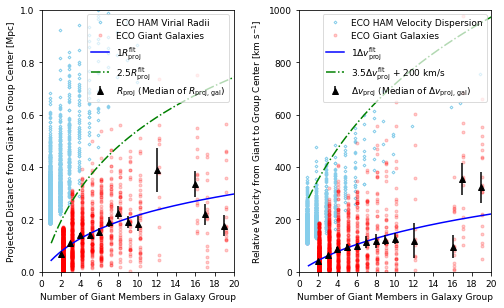

In [9]:
%matplotlib inline
fig, (ax,ax1) = plt.subplots(ncols=2, figsize=doublecolsize)
sel = (ecogiantgrpn>1)
ax1.plot(gihalon-0.2, gihalovdisp, 'D', label=r'ECO HAM Velocity Dispersion', rasterized=True, ms=2, markerfacecolor="None", markeredgecolor='skyblue')
ax1.plot(ecogiantgrpn[sel]+0.1, relvel[sel], 'r.', alpha=0.2, label=r'ECO Giant Galaxies', rasterized=True)
ax1.errorbar(uniqecogiantgrpn[keepcalsel], median_relvel, fmt='k^', label=r'$\Delta v_{\rm proj}$ (Median of $\Delta v_{\rm proj,\, gal}$)',yerr=dvproj_median_error, rasterized=True, zorder=15)
tx = np.linspace(1,max(ecogiantgrpn),1000)
ax1.plot(tx, giantmodel(tx, *poptdvproj), label=r'$1\Delta v_{\rm proj}^{\rm fit}$', rasterized=True, color='blue')
ax1.plot(tx, 3.5*giantmodel(tx, *poptdvproj)+200, 'g',  label=r'$3.5\Delta v_{\rm proj}^{\rm fit}$ + 200 km/s', linestyle='-.', rasterized=True)

ax1.set_xlim(0,20)
ax1.set_ylim(0,1000)
ax1.set_xticks(np.arange(0,22,2))
ax1.set_xlabel("Number of Giant Members in Galaxy Group")
ax1.set_ylabel(r"Relative Velocity from Giant to Group Center [km s$^{-1}$]")
ax1.legend(loc='upper right', framealpha=0.7)

ax.plot(gihalon-0.1, gihalorvir, 'D', markeredgecolor='skyblue', markerfacecolor="None", ms=2, label=r'ECO HAM Virial Radii', rasterized=True)
ax.plot(ecogiantgrpn[sel]+0.2, relprojdist[sel], 'r.', alpha=0.2, label=r'ECO Giant Galaxies', rasterized=True)
ax.errorbar(uniqecogiantgrpn[keepcalsel], median_relprojdist, fmt='k^', label=r'$R_{\rm proj}$ (Median of $R_{\rm proj,\, gal}$)',yerr=rproj_median_error, rasterized=True, zorder=15)
ax.plot(tx, giantmodel(tx, *poptrproj), label=r'$1R_{\rm proj}^{\rm fit}$', rasterized=True, color='blue')
ax.plot(tx, 2.5*giantmodel(tx, *poptrproj), 'g', label=r'$2.5R_{\rm proj}^{\rm fit}$', linestyle='-.', rasterized=True)
ax.set_xlabel("Number of Giant Members in Galaxy Group")
ax.set_ylabel(r"Projected Distance from Giant to Group Center [Mpc]")
ax.legend(loc='best', framealpha=0.7)
ax.set_xlim(0,20)
ax.set_ylim(0,1)
ax.set_xticks(np.arange(0,22,2))
plt.tight_layout()
plt.savefig("../figures/rproj_calibration_assoc.pdf")
plt.show()

In [10]:
len(ecogiantgrpn[ecogiantgrpn>10])/len(ecogiantgrpn), max(ecogiantgrpn)

(0.06194880619488062, 128)

# Giant-only Group Multiplicity Function
should compare before and iterative combination in this plot

In [11]:
ecodata = pd.read_csv("ECOdata_G3catalog_luminosity.csv")
econame = np.array(ecodata.name)
ecoresname = np.array(ecodata.resname)
ecoradeg = np.array(ecodata.radeg)
ecodedeg = np.array(ecodata.dedeg)
ecocz = np.array(ecodata.cz)
ecoabsrmag = np.array(ecodata.absrmag)
ecogiantsel = (ecodata.absrmag<-19.5)
ecogiantfofid = fof.fast_fof(ecoradeg[ecogiantsel],ecodedeg[ecogiantsel],ecocz[ecogiantsel],0.07,1.1,3.39/0.7,H0=70.)

FoF complete in 3.2853 s


In [12]:
resbdata = pd.read_csv("RESOLVEdata_G3catalog_luminosity.csv")
resbdata = resbdata[resbdata.f_b==1]
resbname = np.array(resbdata.name)
resbradeg = np.array(resbdata.radeg)
resbdedeg = np.array(resbdata.dedeg)
resbcz = np.array(resbdata.cz)
resbabsrmag = np.array(resbdata.absrmag)
resbgiantsel = (resbdata.absrmag<-19.5)
resbgiantfofid = fof.fast_fof(resbradeg[resbgiantsel],resbdedeg[resbgiantsel],resbcz[resbgiantsel],0.07,1.1,3.39/0.7,H0=70.)

FoF complete in 0.0058 s


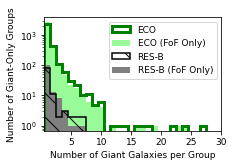

In [13]:

plt.figure(figsize=(singlecolsize[0],1.1*singlecolsize[1]))
binv = np.arange(0.5,100.5,1)

eco = pd.read_csv("ECOdata_G3catalog_luminosity.csv")
ecogiantsel = (eco.absrmag<-19.5)
resolve = pd.read_csv("RESOLVEdata_G3catalog_luminosity.csv")
resb = resolve[(resolve.fl_insample==1)&(resolve.f_b==1)]

plt.hist(fof.multiplicity_function(eco.g3grp_l[ecogiantsel], return_by_galaxy=False), bins=binv, histtype='step', linewidth=3, label='ECO', color='green')
plt.hist(fof.multiplicity_function(ecogiantfofid,return_by_galaxy=False), bins=binv, histtype='stepfilled', color='palegreen', label='ECO (FoF Only)')

resbgiantsel = (resb.absrmag<-19.5)
plt.hist(fof.multiplicity_function(resb.g3grp_l[resbgiantsel], return_by_galaxy=False), bins=binv, histtype='step', linewidth=1.5, hatch='\\', label='RES-B', color='k')
plt.hist(fof.multiplicity_function(resbgiantfofid,return_by_galaxy=False),bins=binv,histtype='stepfilled',color='gray', label='RES-B (FoF Only)')
plt.xlabel("Number of Giant Galaxies per Group")
plt.ylabel("Number of Giant-Only Groups")
plt.yscale('log')
plt.legend(loc='best')
plt.xlim(0.5,30)
plt.tight_layout()
plt.savefig("../figures/giantonlymult.pdf")
plt.show()

# Boundaries for Dwarf-Only Group Finding

In [14]:
ecodata = pd.read_csv("ECOdata_G3catalog_luminosity.csv")
#ecodata=ecodata[ecodata.absrmag<=-19.5]
ecoradeg = ecodata['radeg'].to_numpy()
ecodedeg = ecodata['dedeg'].to_numpy()
ecocz = ecodata['cz'].to_numpy()
ecoabsrmag = ecodata['absrmag'].to_numpy()
ecog3grp = ecodata['g3grp_l'].to_numpy()


In [15]:
ecogdgrpn = fof.multiplicity_function(ecog3grp, return_by_galaxy=True)
ecogdsel = np.logical_not(np.logical_or(ecog3grp==-99., ((ecogdgrpn==1) & (ecoabsrmag>-19.5) & (ecoabsrmag<=-17.33)))) #-17.33 not -17.0 (2/22/21)
ecogdgrpra, ecogdgrpdec, ecogdgrpcz = fof.group_skycoords(ecoradeg[ecogdsel], ecodedeg[ecogdsel], ecocz[ecogdsel], ecog3grp[ecogdsel])
ecogdrelvel = np.abs(ecogdgrpcz - ecocz[ecogdsel])
ecogdrelprojdist = (ecogdgrpcz + ecocz[ecogdsel])/HUBBLE_CONST * np.sin(ic.angular_separation(ecogdgrpra, ecogdgrpdec, ecoradeg[ecogdsel], ecodedeg[ecogdsel])/2.0)
ecogdn = ecogdgrpn[ecogdsel]
ecogdtotalmag = ic.get_int_mag(ecoabsrmag[ecogdsel], ecog3grp[ecogdsel])

magbins=np.arange(-24,-19,0.25)
binsel = np.where(np.logical_and(ecogdn>1, ecogdtotalmag>-24)) # test here
gdmedianrproj, magbincenters, agbinedges, jk = center_binned_stats(ecogdtotalmag[binsel], ecogdrelprojdist[binsel], np.median, bins=magbins)
gdmedianrproj_err, jk, jk, jk = center_binned_stats(ecogdtotalmag[binsel], ecogdrelprojdist[binsel], sigmarange, bins=magbins)
gdmedianrelvel, jk, jk, jk = center_binned_stats(ecogdtotalmag[binsel], ecogdrelvel[binsel], np.median, bins=magbins)
gdmedianrelvel_err, jk, jk, jk = center_binned_stats(ecogdtotalmag[binsel], ecogdrelvel[binsel], sigmarange, bins=magbins)
nansel = np.isnan(gdmedianrproj)

In [16]:
if 0: 
    guess=None
else:
    guess=[1e-5, 0.4]
poptr, pcovr = curve_fit(decayexp, magbincenters[~nansel], gdmedianrproj[~nansel], p0=guess)
poptv, pcovv = curve_fit(decayexp, magbincenters[~nansel], gdmedianrelvel[~nansel], p0=[3e-5,4e-1])#,1])
print('dwarf only model params: ', poptr, poptv)
print('errors: ', np.sqrt(np.abs(np.diag(pcovr))), np.sqrt(np.abs(np.diag(pcovv))))

dwarf only model params:  [1.99433681e-06 4.94143299e-01] [0.00752787 0.40735245]
errors:  [1.26889030e-06 2.76103579e-02] [0.00377514 0.02190714]


Fraction outside of iterative combination boundaries: 
0.05641025641025641
0.013675213675213675


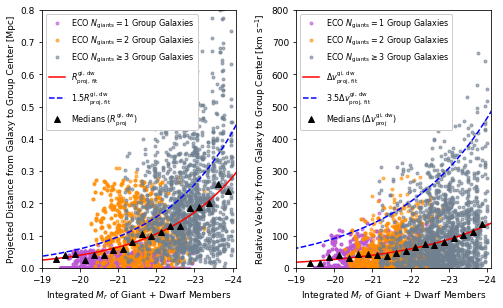

In [19]:
tx = np.linspace(-27,-17,100)
fig, (ax,ax1) = plt.subplots(ncols=2, figsize=doublecolsize)

giantgrpn = np.array([np.sum((ecoabsrmag[ecogdsel][ecog3grp[ecogdsel]==gg]<-19.5)) for gg in ecog3grp[ecogdsel]])
sel_ = np.where(np.logical_and(giantgrpn==1,ecogdtotalmag>-24))
ax.plot(ecogdtotalmag[sel_], ecogdrelprojdist[sel_], '.', color='mediumorchid', alpha=0.6, label=r'ECO $N_{\rm giants}=1$ Group Galaxies', rasterized=True)
sel_ = np.where(np.logical_and(giantgrpn==2,ecogdtotalmag>-24))
ax.plot(ecogdtotalmag[sel_], ecogdrelprojdist[sel_], '.', color='darkorange', alpha=0.6, label=r'ECO $N_{\rm giants}=2$ Group Galaxies', rasterized=True)
sel_ = np.where(np.logical_and(giantgrpn>2,ecogdtotalmag>-24))
ax.plot(ecogdtotalmag[sel_], ecogdrelprojdist[sel_], '.', color='slategrey', alpha=0.6, label=r'ECO $N_{\rm giants}\geq3$ Group Galaxies', rasterized=True)
#ax.errorbar(magbincenters, gdmedianrproj, yerr=gdmedianrproj_err, fmt='k^', label=r'Medians ($R_{\rm proj}^{\rm gi,\,dw}$)', rasterized=True, zorder=15)
ax.errorbar(magbincenters, gdmedianrproj, yerr=None, fmt='k^', label=r'Medians ($R_{\rm proj}^{\rm gi,\,dw}$)', rasterized=True, zorder=15)
ax.plot(tx, 1*decayexp(tx,*poptr), color='red', label=r'$R_{\rm proj,\,fit}^{\rm gi,\, dw}$', rasterized=True)
ax.plot(tx, 1.5*decayexp(tx,*poptr), color='blue', label=r'$1.5R_{\rm proj,\,fit}^{\rm gi,\, dw}$', rasterized=True,linestyle='--')
#ax.plot(tx, 3*decayexp(tx,*poptr), label=r'$3R_{\rm proj,\,fit}^{\rm gi,\, dw}$', rasterized=True)
ax.set_xlabel(r"Integrated $M_r$ of Giant + Dwarf Members")
ax.set_ylabel(r"Projected Distance from Galaxy to Group Center [Mpc]")
ax.legend(loc='best',fontsize=8,framealpha=1)
ax.set_xlim(-24.1,-19)
ax.set_ylim(0,0.8)
ax.invert_xaxis()

#ax1.plot(ecogdtotalmag[binsel], ecogdrelvel[binsel], '.', alpha=0.6, label='ECO Giant-Hosting Group Galaxies', rasterized=True, color='palegreen')
#ax1.errorbar(magbincenters, gdmedianrelvel, yerr=gdmedianrelvel_err, fmt='k^',label=r'Medians ($\Delta v_{\rm proj}^{\rm gi,\,dw}$)', rasterized=True, zorder=15)
ax1.errorbar(magbincenters, gdmedianrelvel, yerr=None, fmt='k^',label=r'Medians ($\Delta v_{\rm proj}^{\rm gi,\,dw}$)', rasterized=True, zorder=15)
sel_ = np.where(np.logical_and(giantgrpn==1,ecogdtotalmag>-24))
ax1.plot(ecogdtotalmag[sel_], ecogdrelvel[sel_], '.', color='mediumorchid', alpha=0.6, label=r'ECO $N_{\rm giants}=1$ Group Galaxies', rasterized=True)
sel_ = np.where(np.logical_and(giantgrpn==2,ecogdtotalmag>-24))
ax1.plot(ecogdtotalmag[sel_], ecogdrelvel[sel_], '.', color='darkorange', alpha=0.6, label=r'ECO $N_{\rm giants}=2$ Group Galaxies', rasterized=True)
sel_ = np.where(np.logical_and(giantgrpn>2,ecogdtotalmag>-24))
ax1.plot(ecogdtotalmag[sel_], ecogdrelvel[sel_], '.', color='slategrey', alpha=0.6, label=r'ECO $N_{\rm giants}\geq3$ Group Galaxies', rasterized=True)
ax1.plot(tx, decayexp(tx, *poptv), color='red', label=r'$\Delta v_{\rm proj,\, fit}^{\rm gi,\, dw}$', rasterized=True)
ax1.plot(tx, 3.5*decayexp(tx, *poptv), color='blue', label=r'$3.5\Delta v_{\rm proj,\, fit}^{\rm gi,\, dw}$', rasterized=True, linestyle='--')
ax1.set_ylabel(r"Relative Velocity from Galaxy to Group Center [km s$^{-1}]$")
ax1.set_xlabel(r"Integrated $M_r$ of Giant + Dwarf Members")
print("Fraction outside of iterative combination boundaries: ")
print(np.sum(ecogdrelprojdist[binsel]>3*decayexp(ecogdtotalmag[binsel],*poptr))/len(ecogdtotalmag[binsel]))
print(np.sum(ecogdrelvel[binsel]>4.5*decayexp(ecogdtotalmag[binsel],*poptv))/len(ecogdtotalmag[binsel]))
ax1.set_xlim(-24.1,-19)
ax1.set_ylim(0,800)
ax1.invert_xaxis()
ax1.legend(loc='best',fontsize=8, framealpha=1)
plt.tight_layout()
plt.savefig("../figures/itercombboundaries.pdf")
plt.show()

# $M_{\rm halo} - L_{\rm tot}$ Curve

In [20]:
ecodata = pd.read_csv("ECOdata_G3catalog_luminosity.csv")
sel = (ecodata.g3logmh_l>0)
ecologmh = ecodata.g3logmh_l[sel]
ecoLtot = ic.get_int_mag(ecodata[sel].absrmag.to_numpy(), ecodata[sel].g3grp_l.to_numpy())

In [21]:
resolve = pd.read_csv("RESOLVEdata_G3catalog_luminosity.csv")
resb = resolve[(resolve.fl_insample==1)&(resolve.f_b==1)]
resblogmh = resb.g3logmh_l
resbLtot = ic.get_int_mag(resb.absrmag.to_numpy(),resb.g3grp_l.to_numpy())

In [22]:
resbana = pd.read_csv("resbanalogue.csv")
resbana = resbana[resbana.g3logmh_l>0]

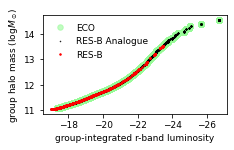

In [23]:
plt.figure(figsize=singlecolsize)
plt.plot(ecoLtot, ecologmh, '.', color='palegreen', alpha=0.6, label='ECO', markersize=11, rasterized=True)
plt.plot(resbana.g3grpabsrmag_l, resbana.g3logmh_l, 'k.', markersize=1, label='RES-B Analogue')
plt.plot(resbLtot, resblogmh, '.', color='red', alpha=1, label='RES-B', markersize=3, rasterized=True)
plt.xlabel("group-integrated r-band luminosity")
plt.ylabel(r"group halo mass (log$M_\odot$)")
plt.legend(loc='best',framealpha=0)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig("../figures/hamLrrelationG3.pdf")
plt.show()

# G3 vs. FoF Multiplicity Functions

In [24]:
ecodata = pd.read_csv("ECOdata_G3catalog_luminosity.csv")
ecodata = ecodata[ecodata.g3grp_l>0]
ecoradeg = ecodata['radeg'].to_numpy()
ecodedeg = ecodata['dedeg'].to_numpy()
ecocz = ecodata['cz'].to_numpy()
ecoabsrmag = ecodata['absrmag'].to_numpy()
ecog3grp = ecodata['g3grp_l'].to_numpy()

In [25]:
resolvedata = pd.read_csv("RESOLVEdata_G3catalog_luminosity.csv")
resbdata = resolvedata[(resolvedata.f_b==1)&(resolvedata.g3grp_l>0)]
resbdata = resbdata[resbdata.g3grp_l>0]
resbradeg = resbdata['radeg'].to_numpy()
resbdedeg = resbdata['dedeg'].to_numpy()
resbcz = resbdata['cz'].to_numpy()
resbabsrmag = resbdata['absrmag'].to_numpy()
resbg3grp = resbdata['g3grp_l'].to_numpy()

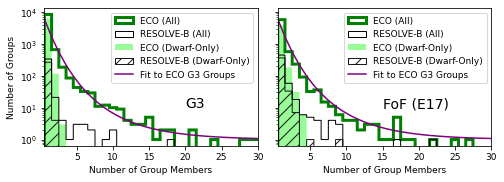

K-S test for G3 vs. FOF E17 Mult. Functions (ECO):
KstestResult(statistic=0.039175315884476536, pvalue=0.3745250497926178)
KstestResult(statistic=0.031595498646209384, pvalue=0.3349780278708195)
KstestResult(statistic=0.039175315884476536, pvalue=0.18784894157184523)
hellinger distance: 
0.05909758492930784


In [26]:
binv = np.arange(0.5,1200.5,1)
g3mult=np.array(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False))
g3hist, binedges = np.histogram(g3mult,bins=binv)
bincenters=0.5*(binedges[1:]+binedges[:-1])
sel=(g3hist>0)
g3popt, g3pcov = curve_fit(decayexp, bincenters[sel],np.log10(g3hist[sel]))

fig, (ax,ax2) = plt.subplots(figsize=(doublecolsize[0],0.6*doublecolsize[1]), ncols=2, sharey=True)
binv = np.arange(0.5,1200.5,1)
ax.hist(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax.hist(fof.multiplicity_function(resbg3grp[resbg3grp!=-99.], return_by_galaxy=False), bins=binv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
ax.set_xlabel("Number of Group Members")
ax.annotate("G3",xy=(20,10),fontsize=14)
ax.set_ylabel("Number of Groups")
ax.set_xlim(0.5,30)

binvd=binv
ecodwarfonly = ecodata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax.hist(fof.multiplicity_function(ecodwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False), bins=binvd, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
resbdwarfonly = resbdata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax.hist(fof.multiplicity_function(resbdwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False), bins=binvd, log=True, histtype='step', alpha=0.9, color='k', hatch='//', label='RESOLVE-B (Dwarf-Only)')
ax.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax.legend(loc='best')


ecodr2=pd.read_csv("ECODR2.csv")
ecodr2=ecodr2[ecodr2.absrmag<-17.33] 
ax2.hist(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax2.hist(fof.multiplicity_function(np.array(resolvedata.grp_e17[(resolvedata.f_b==1)&(resolvedata.grp_e17!=-99.)]), return_by_galaxy=False), bins=binv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
fofdwarfonly = ecodr2[(ecodr2.grp_e17!=-99.)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax2.hist(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False), bins=binvd, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
fofdwarfonly = resolvedata[(resolvedata.grp_e17!=-99.)&(resolvedata.f_b==1)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax2.hist(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False), bins=binvd, log=True, histtype='step', color='k', alpha=0.9, hatch='//', label='RESOLVE-B (Dwarf-Only)')
ax2.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax2.annotate("FoF (E17)",xy=(15,10),fontsize=14)
ax2.set_xlim(0.5,30)
ax2.set_xlabel("Number of Group Members")
ax2.legend(loc='best')
plt.tight_layout()
plt.savefig("../figures/multfunc_doinset.pdf")
plt.show()

print("K-S test for G3 vs. FOF E17 Mult. Functions (ECO):")
fofmult=np.array(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False))
g3mult=np.array(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False))
print(kstest(g3mult[g3mult>1],fofmult[fofmult>1]))
print(kstest(g3mult[g3mult>1],fofmult[fofmult>1],'less'))
print(kstest(g3mult[g3mult>1],fofmult[fofmult>1],'greater'))
print("hellinger distance: ")
g3hist,_ = np.histogram(g3mult,bins=binv,density=True)
fofhist,_ = np.histogram(fofmult,bins=binv,density=True)
print(hellinger2(g3hist,fofhist))

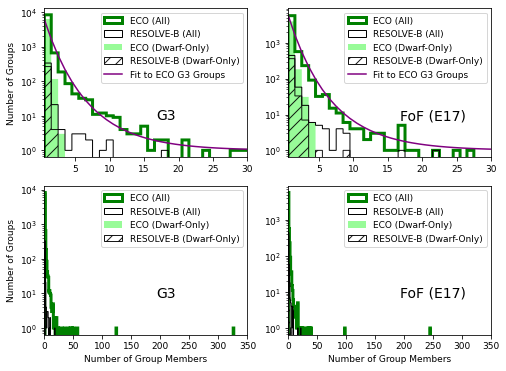

K-S test for G3 vs. FOF E17 Mult. Functions (ECO):
KstestResult(statistic=0.039175315884476536, pvalue=0.3745250497926178)
KstestResult(statistic=0.031595498646209384, pvalue=0.3349780278708195)
KstestResult(statistic=0.039175315884476536, pvalue=0.18784894157184523)
hellinger distance: 
0.05909758492930784


In [27]:
binv = np.arange(0.5,1200.5,1)
g3mult=np.array(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False))
g3hist, binedges = np.histogram(g3mult,bins=binv)
bincenters=0.5*(binedges[1:]+binedges[:-1])
sel=(g3hist>0)
g3popt, g3pcov = curve_fit(decayexp, bincenters[sel],np.log10(g3hist[sel]))

fig, ((ax,ax2), (ax3,ax4)) = plt.subplots(figsize=(doublecolsize[0],1.2*doublecolsize[1]), ncols=2, nrows=2)
binv = np.arange(0.5,1200.5,1)
ax.hist(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax.hist(fof.multiplicity_function(resbg3grp[resbg3grp!=-99.], return_by_galaxy=False), bins=binv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
ax.annotate("G3",xy=(0.55,0.25),fontsize=14,xycoords='axes fraction')
ax.set_ylabel("Number of Groups")
ax.set_xlim(0.5,30)

binvd=binv
ecodwarfonly = ecodata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax.hist(fof.multiplicity_function(ecodwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False), bins=binvd, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
resbdwarfonly = resbdata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax.hist(fof.multiplicity_function(resbdwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False), bins=binvd, log=True, histtype='step', alpha=0.9, color='k', hatch='//', label='RESOLVE-B (Dwarf-Only)')
ax.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax.legend(loc='best')

ax3.hist(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax3.hist(fof.multiplicity_function(resbg3grp[resbg3grp!=-99.], return_by_galaxy=False), bins=binv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
ax3.set_xlabel("Number of Group Members")
ax3.annotate("G3",xy=(0.55,0.25),fontsize=14, xycoords='axes fraction')
ax3.set_ylabel("Number of Groups")
ax3.set_xlim(0.5,30)

binvd=binv
ecodwarfonly = ecodata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax3.hist(fof.multiplicity_function(ecodwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False), bins=binvd, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
resbdwarfonly = resbdata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax3.hist(fof.multiplicity_function(resbdwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False), bins=binvd, log=True, histtype='step', alpha=0.9, color='k', hatch='//', label='RESOLVE-B (Dwarf-Only)')
#ax3.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax3.legend(loc='best')
ax3.set_xlim(0,350)
ax3.set_xlabel("Number of Group Members")
ax3.set_ylabel("Number of Groups")


##############

ecodr2=pd.read_csv("ECODR2.csv")
ecodr2=ecodr2[ecodr2.absrmag<-17.33] 
ax2.hist(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax2.hist(fof.multiplicity_function(np.array(resolvedata.grp_e17[(resolvedata.f_b==1)&(resolvedata.grp_e17!=-99.)]), return_by_galaxy=False), bins=binv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
fofdwarfonly = ecodr2[(ecodr2.grp_e17!=-99.)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax2.hist(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False), bins=binvd, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
fofdwarfonly = resolvedata[(resolvedata.grp_e17!=-99.)&(resolvedata.f_b==1)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax2.hist(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False), bins=binvd, log=True, histtype='step', color='k', alpha=0.9, hatch='//', label='RESOLVE-B (Dwarf-Only)')
ax2.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax2.annotate("FoF (E17)",xy=(0.55,0.25),fontsize=14,xycoords='axes fraction')
ax2.set_xlim(0.5,30)
ax2.legend(loc='best')

ax4.hist(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax4.hist(fof.multiplicity_function(np.array(resolvedata.grp_e17[(resolvedata.f_b==1)&(resolvedata.grp_e17!=-99.)]), return_by_galaxy=False), bins=binv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
fofdwarfonly = ecodr2[(ecodr2.grp_e17!=-99.)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax4.hist(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False), bins=binvd, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
fofdwarfonly = resolvedata[(resolvedata.grp_e17!=-99.)&(resolvedata.f_b==1)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax4.hist(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False), bins=binvd, log=True, histtype='step', color='k', alpha=0.9, hatch='//', label='RESOLVE-B (Dwarf-Only)')
#ax4.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax4.annotate("FoF (E17)",xy=(0.55,0.25),fontsize=14, xycoords='axes fraction')
ax4.legend(loc='best')
ax4.set_xlim(0,350)
ax4.set_xlabel("Number of Group Members")

plt.tight_layout()
plt.savefig("../figures/multfunc_doinset.pdf")
plt.show()

print("K-S test for G3 vs. FOF E17 Mult. Functions (ECO):")
fofmult=np.array(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False))
g3mult=np.array(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False))
print(kstest(g3mult[g3mult>1],fofmult[fofmult>1]))
print(kstest(g3mult[g3mult>1],fofmult[fofmult>1],'less'))
print(kstest(g3mult[g3mult>1],fofmult[fofmult>1],'greater'))
print("hellinger distance: ")
g3hist,_ = np.histogram(g3mult,bins=binv,density=True)
fofhist,_ = np.histogram(fofmult,bins=binv,density=True)
print(hellinger2(g3hist,fofhist))

In [28]:
g3hist, binedges = np.histogram(g3mult,bins=binv)
fofhist,binedges = np.histogram(fofmult,bins=binv)

bincenters=0.5*(binedges[1:]+binedges[:-1])
sel=(g3hist>0)
g3popt, g3pcov = curve_fit(decayexp, bincenters[sel],np.log10(g3hist[sel]))
sel=(fofhist>0)
fofpopt, fofpcov = curve_fit(decayexp, bincenters[sel],np.log10(fofhist[sel]))

In [29]:
print(g3popt,np.sqrt(np.diagonal(g3pcov)))
print(fofpopt,np.sqrt(np.diagonal(fofpcov)))

[ 4.09748562 -0.16061424] [0.15678242 0.00819038]
[ 4.31386516 -0.19090323] [0.16982482 0.00970677]


# Dwarf-only group sizes 

In [41]:
ecodata = pd.read_csv("ECOdata_G3catalog_luminosity.csv")
ecodata = ecodata[ecodata.g3grp_l>0]
ecoradeg = ecodata['radeg'].to_numpy()
ecodedeg = ecodata['dedeg'].to_numpy()
ecocz = ecodata['cz'].to_numpy()
ecoabsrmag = ecodata['absrmag'].to_numpy()
ecog3grp = ecodata['g3grp_l'].to_numpy()

In [42]:
ecodwarfonly = ecodata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ecodwarfonly.loc[:,'grpn']=fof.multiplicity_function(ecodwarfonly.g3grp_l.to_numpy(),return_by_galaxy=True)

In [43]:
rproj, czdisp = fof.get_rproj_czdisp(ecodwarfonly.radeg.to_numpy(), ecodwarfonly.dedeg.to_numpy(), ecodwarfonly.cz.to_numpy(),\
                                    ecodwarfonly.g3grp_l.to_numpy(), 70.)
ecodwarfonly.loc[:,'obsrproj']=rproj
ecodwarfonly = ecodwarfonly.groupby('g3grp_l').first()
ecodwarfonly = ecodwarfonly[(ecodwarfonly.obsrproj>0)&(ecodwarfonly.grpn>1)]
rproj = ecodwarfonly.obsrproj.to_numpy()

print(np.min(rproj), np.median(rproj), np.max(rproj), len(rproj))

0.0005739466336494836 0.018600791523835526 0.06829373066138447 119


In [44]:
fofdwarfonly = ecodr2[(ecodr2.grp_e17!=-99.)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
fofdwarfonly.loc[:,'grpn']=fof.multiplicity_function(fofdwarfonly.grp_e17.to_numpy(),True)

In [45]:
rproj, czdisp = fof.get_rproj_czdisp(fofdwarfonly.radeg.to_numpy(), fofdwarfonly.dedeg.to_numpy(), fofdwarfonly.cz.to_numpy(),\
                                    fofdwarfonly.grp_e17.to_numpy(), 70.)
fofdwarfonly.loc[:,'obsrproj']=rproj
fofdwarfonly = fofdwarfonly.groupby('grp_e17').first()
fofdwarfonly = fofdwarfonly[(fofdwarfonly.obsrproj>0)&(fofdwarfonly.grpn>1)]
rproj = fofdwarfonly.obsrproj.to_numpy()

print(np.min(rproj), np.median(rproj), np.max(rproj), len(rproj))

0.000580013959874567 0.03957142399050333 0.167791724175728 220


In [46]:
mock = pd.read_hdf("../halobiasmocks/fiducial/ECO_cat_0_Planck_memb_cat.hdf5")
mock = mock.groupby('haloid').filter(lambda hh: (hh.M_r>-19.5).any())

In [47]:
rproj, czdisp = fof.get_rproj_czdisp(mock.ra.to_numpy(), mock.dec.to_numpy(), mock.cz.to_numpy(),\
                                    mock.haloid.to_numpy(), 70.)
mock.loc[:,'obsrproj']=rproj
mock = mock.groupby('haloid').first()
mock = mock[(mock.obsrproj>0)&(mock.g_ngal>1)]
rproj = mock.obsrproj.to_numpy()

print(np.min(rproj), np.median(rproj), np.max(rproj), len(rproj))

8.356475665958852e-05 0.029190452184889026 0.5681223720320642 1696


In [37]:
decayexp(-18,*poptr)

0.014543376672226908

# number of pairs in G3

In [38]:
g3 = pd.read_csv("ECOdata_G3catalog_luminosity.csv")
g3=g3[g3.g3grp_l>0]

In [39]:
grpn=np.array(fof.multiplicity_function(g3.g3grp_l.to_numpy(),False))
print(grpn)

[1 2 5 ... 1 1 1]


In [40]:
np.sum(grpn==2)

658